# Analysis of data from META

Data fetched from Meta's Community Standards Enforcement Report

### Imports

In [92]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### Load Data

In [93]:
path = "../data/CSER-2025_Q4.csv"
df = pd.read_csv(path)
df.head()


,app,policy_area,metric,period,value
0,Facebook,Adult Nudity & Sexual Activity,Content Actioned,2017Q4,"20,800,000"
1,Facebook,Adult Nudity & Sexual Activity,Content Actioned,2018Q1,"21,000,000"
2,Facebook,Adult Nudity & Sexual Activity,Content Actioned,2018Q2,"34,900,000"
3,Facebook,Adult Nudity & Sexual Activity,Content Actioned,2018Q3,"31,800,000"
4,Facebook,Adult Nudity & Sexual Activity,Content Actioned,2018Q4,"28,700,000"


Fetch instagram data

In [94]:
df_instagram = df[df["app"]=="Instagram"].copy()
df_instagram = df_instagram.reset_index(drop=True)
df_instagram.head()


,app,policy_area,metric,period,value
0,Instagram,Adult Nudity & Sexual Activity,Content Actioned,2017Q4,NaN
1,Instagram,Adult Nudity & Sexual Activity,Content Actioned,2018Q1,NaN
2,Instagram,Adult Nudity & Sexual Activity,Content Actioned,2018Q2,NaN
3,Instagram,Adult Nudity & Sexual Activity,Content Actioned,2018Q3,NaN
4,Instagram,Adult Nudity & Sexual Activity,Content Actioned,2018Q4,NaN


Find policy areas

In [95]:
print(df_instagram["policy_area"].unique())

['Adult Nudity & Sexual Activity' 'Bullying & Harassment'
 'Child Endangerment: Nudity and Physical Abuse'
 'Child Endangerment: Sexual Exploitation'
 'Child Nudity & Sexual Exploitation'
 'Dangerous Organizations: Organized Hate'
 'Dangerous Organizations: Terrorism' 'Hateful Conduct'
 'Restricted Goods & Services: Drugs'
 'Restricted Goods & Services: Firearms' 'Spam'
 'Suicide, Self-Injury, and Eating Disorders' 'Violence and Incitement'
 'Violent and Graphic Content' 'Cross-Policy Data']


We will consider "Hateful Conduct"

Now, we find the unique metrics:

In [96]:
df_instagram_hate = df_instagram[df_instagram["policy_area"]=="Hateful Conduct"].copy()
df_instagram_hate = df_instagram_hate.reset_index(drop=True)
print(df_instagram_hate["metric"].unique())

['Content Actioned' 'Content Appealed' 'Content Restored with appeal'
 'Content Restored without appeal' 'Lowerbound Prevalence'
 'Proactive rate' 'Upperbound Prevalence']


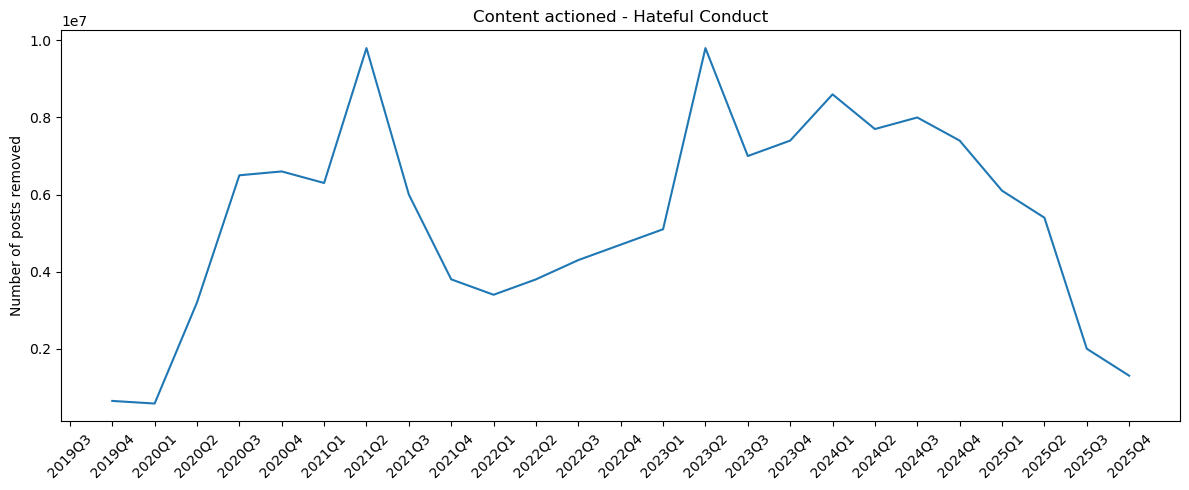

In [97]:
df_plot = df_instagram_hate[df_instagram_hate["metric"]=="Content Actioned"].copy()
df_plot.dropna()
df_plot["value"] = df_plot["value"].str.replace(",", "").astype(float)
plt.figure(figsize=(12, 5))
plt.plot(df_plot["period"], df_plot["value"])
plt.xticks(rotation=45)
plt.title("Content actioned - Hateful Conduct")
plt.ylabel("Number of posts removed")
plt.tight_layout()
plt.show()

Plotting prevalence:

<class 'str'>
<class 'numpy.float64'>


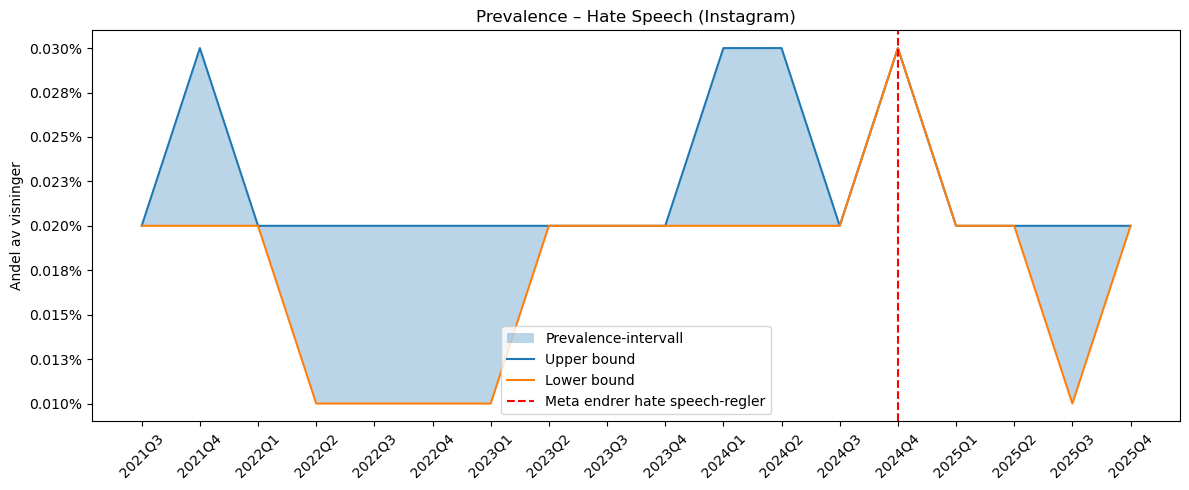

In [98]:
df_plot = df_instagram_hate[(df_instagram_hate["metric"]=="Upperbound Prevalence") \
    | (df_instagram_hate["metric"]=="Lowerbound Prevalence")].copy()
df_plot = df_plot.reset_index(drop=True)
print(type(df_plot["value"][1]))
df_plot["value"] = df_plot["value"].str.replace("%", "").astype(float)/100
print(type(df_plot["value"][1]))
df_plot.head()
df_plot = df_plot.dropna()


upper = df_plot[df_plot["metric"] == "Upperbound Prevalence"]
lower = df_plot[df_plot["metric"] == "Lowerbound Prevalence"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(upper["period"], lower["value"], upper["value"], alpha=0.3, label="Prevalence-intervall")
ax.plot(upper["period"], upper["value"], label="Upper bound")
ax.plot(lower["period"], lower["value"], label="Lower bound")

ax.axvline(x="2024Q4", color="red", linestyle="--", linewidth=1.5, label="Meta endrer hate speech-regler")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=3))
ax.set_xticks(range(len(upper["period"])))
ax.set_xticklabels(upper["period"], rotation=45)
ax.legend()
ax.set_title("Prevalence – Hate Speech (Instagram)")
ax.set_ylabel("Andel av visninger")
plt.tight_layout()
plt.show()




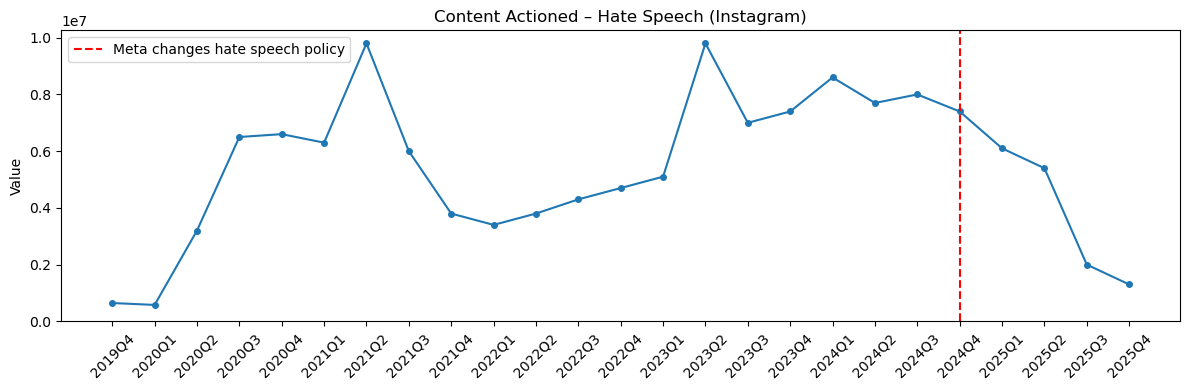

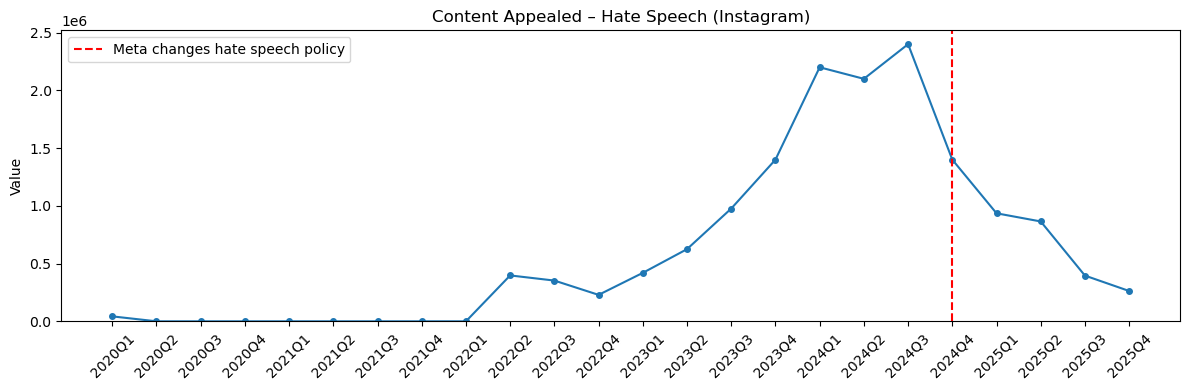

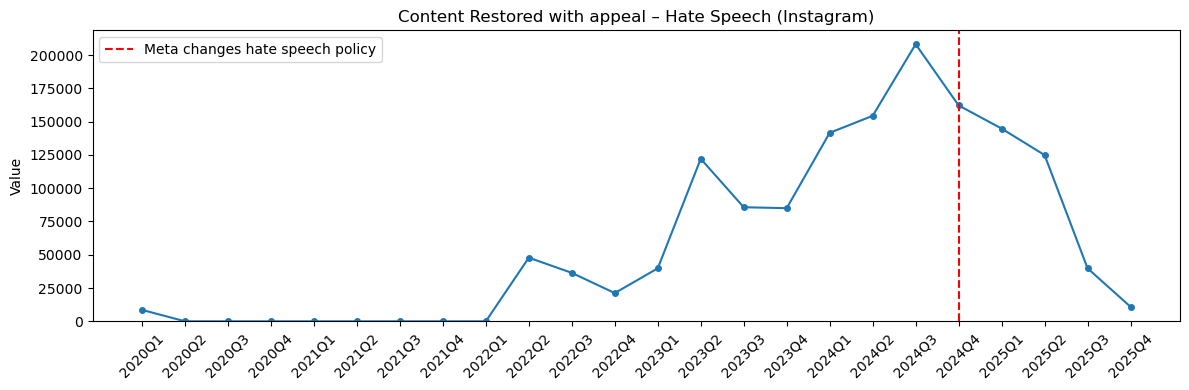

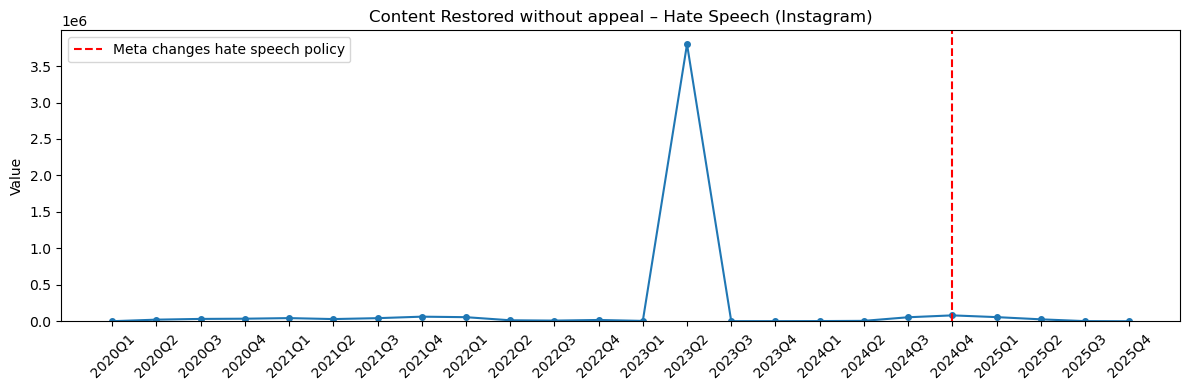

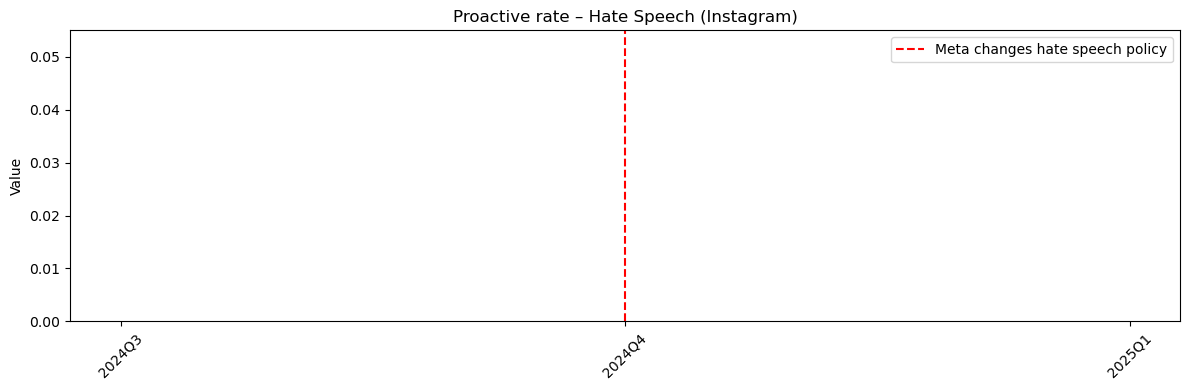

In [99]:
metrics = [
    "Content Actioned",
    "Content Appealed",
    "Content Restored with appeal",
    "Content Restored without appeal",
    "Proactive rate"
]

for metric in metrics:
    df_m = df_instagram_hate[df_instagram_hate["metric"] == metric].copy()
    df_m = df_m.dropna(subset=["value"]).reset_index(drop=True)
    df_m["value"] = pd.to_numeric(df_m["value"].astype(str).str.replace(",", ""), errors="coerce")

    plt.figure(figsize=(12, 4))
    plt.plot(df_m["period"], df_m["value"], marker="o", markersize=4)
    plt.axvline(x="2024Q4", color="red", linestyle="--", linewidth=1.5, label="Meta changes hate speech policy")
    plt.title(metric + " – Hate Speech (Instagram)")
    plt.ylabel("Value")
    plt.ylim(bottom=0)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
